In [1]:
import pandas as pd
from glob import glob
import json
import seaborn as sns
import numpy as np
from scipy.stats import wasserstein_distance
import itertools
import matplotlib.pyplot as plt


In [3]:
#data_dir = "../../chem-poison-godot-param-sweep/2025-08-06-1/"
working_dir = "/home/bl4zc/biocomplexity/dtra/Toxin_Building_2025/chem-poison-godot/analysis/"
#data_dir = "../../chem-poison-godot-param-sweep/2025-09-11-1/"  ## 10 runs
#data_dir = "../../chem-poison-godot-param-sweep/2025-09-15-1/"  ## 20 runs
data_dir = "../../chem-poison-godot-param-sweep/2025-10-02-1/"  ## 50 runs

configs = glob(f"{working_dir}{data_dir}*-config*json")
cfg_list = []

for c in configs:
    cell = c.split("/")[-1].split("-")[0]
    #print(cell,c)
    f = open(c,'r')
    cfg = json.load(f)
    cfg_list.append(cfg)
cfgs = pd.DataFrame(cfg_list)
cfgs['output'] = cfgs.output_file.apply(lambda x:x.split("/")[-1])
cfgs['schedule'] = cfgs.schedule_file.apply(lambda x:x.split("/")[-1])
print(f"Total of {len(cfgs)} configurations loaded.")
cfgs.sample(3)

Total of 5400 configurations loaded.


,person_file,schedule_file,output_file,sim_speed_scale,save_every_s,prob_poison_xfer,person_to_obj_coeff,obj_to_person_coeff,max_person_gain,initial_poison,abs_tick_duration_m,abs_fast_poison_threshold,abs_fast_rate_per_h,abs_slow_frac_rate_per_h,abs_obj_absorption_frac,run_id,cell,replicate,output,schedule
5271,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/scratch/pb5gj/chem-poison-godot-param-sweep/3...,1.0,5,0.33,0.2,0.3,250.0,5000.0,10.0,25,5,0.3,0.3,3810,76,10,3810-output.json,schedule_limitedCR_v4.json
1638,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/scratch/pb5gj/chem-poison-godot-param-sweep/3...,1.0,5,0.33,0.2,0.3,250.0,5000.0,10.0,25,60,0.3,0.3,3952,79,2,3952-output.json,schedule_limitedCR_v4.json
4824,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/scratch/pb5gj/chem-poison-godot-param-sweep/5...,1.0,5,0.10,0.2,0.4,250.0,5000.0,10.0,25,60,0.3,0.3,598,11,48,598-output.json,schedule_limitedCR_v4.json


In [4]:
def tidy_oids_to_names(n):
    ### replace the specific combos first
    n = n.replace("/root/Main/Map/Cafeteria1/Entrance","Cafe-Entrance")
    n = n.replace("/root/Main/Map/Gym1/Entrance","Gym-Entrance")
    n = n.replace("/root/Main/Map/Level1/EntranceContainer/Entrance1","Main-Entrance")

    ## dump the rest (yes there are more elegant ways to do this)
    n = n.replace("/root/Main/Map/Level1/EntranceContainer/","").replace("/root/Main/Map/Level1/ConferenceTableContainer/","")
    n = n.replace("/root/Main/Map/Level1/CubicleContainer/","").replace("/root/Main/Map/Level1/RestroomContainer/","")
    n = n.replace("/root/Main/Map/Level1/WaterCoolerContainer/","")
    n = n.replace("/root/Main/Map/Cafeteria1/","").replace("/root/Main/Map/Gym1/","")
    
    return(n)

In [5]:
objs = pd.read_json(f"{working_dir}../../chem-poison-godot-data/2025-07-01/objects_with_WaterCooler.json")
objs['obj_name'] = objs.oid.apply(lambda x: tidy_oids_to_names(x))
objs.sample(3)

,group,oid,pos_x,pos_y,type,obj_name
69,CA_1_3,/root/Main/Map/Level1/CubicleContainer/Cubicle169,1786,770,cubicle,Cubicle169
235,K_1_1,/root/Main/Map/Cafeteria1/CafeteriaTable4,-1280,2270,cafeteria_table,CafeteriaTable4
98,CA_1_5,/root/Main/Map/Level1/CubicleContainer/Cubicle133,1800,-1374,cubicle,Cubicle133


In [6]:
cfgs.cell.value_counts().describe()

count    108.0
mean      50.0
std        0.0
min       50.0
25%       50.0
50%       50.0
75%       50.0
max       50.0
Name: count, dtype: float64

In [29]:
# params = cfgs.groupby(['prob_poison_xfer', 'person_to_obj_coeff',
#       'obj_to_person_coeff', 'max_person_gain'])['replicate'].count().reset_index().sort_values(by=['max_person_gain','prob_poison_xfer', 'person_to_obj_coeff',
#       'obj_to_person_coeff'])
# params = params[params.replicate == 5]
# params['param_id'] = params.index
# params

In [7]:

short_names = {'prob_poison_xfer':'ppx', 
               'person_to_obj_coeff':'p2o', 
               'obj_to_person_coeff':'o2s',
               'max_person_gain':'mpg'}


In [8]:
def poison_exchange_stats(df):
    df['poison_xfer'] = df.pid_poison_end - df.pid_poison_start
    df = df[df['poison_xfer'] != 0.00]
    
    stats = pd.DataFrame(df.poison_xfer.describe()).T
    return stats

In [32]:
#pexchg.sort_values(by=['pid', 'time'])


# Distance calculation functions

In [9]:
def calculate_distance_and_time(df, condition_col, condition_val):
    """
    Calculates the total Euclidean and Manhattan distance traveled and total time elapsed
    for each person while a condition is met.
    
    Parameters:
    - df: pandas DataFrame with columns ['person_id', 'x', 'y', 'clock', <condition_col>]
    - condition_col: str, name of the column with the condition to check
    - condition_val: value to filter rows where condition is True (e.g., 'active')
    
    Returns:
    - result_df: pandas DataFrame with columns ['person_id', 'euclidean_distance', 'manhattan_distance', 'time_elapsed']
    """

    # Filter to only rows where the condition is True
    df_filtered = df[df[condition_col] >= condition_val].copy()

    # Sort to ensure proper time sequence
    df_filtered.sort_values(by=['pid', 'time'], inplace=True)

    # Shift x, y, and clock for distance and time calculations
    df_filtered['x_prev'] = df_filtered.groupby('pid')['pos_x'].shift()
    df_filtered['y_prev'] = df_filtered.groupby('pid')['pos_y'].shift()
    df_filtered['time_prev'] = df_filtered.groupby('pid')['time'].shift()

    # Calculate distances and time deltas
    df_filtered['euclidean'] = np.sqrt(
        (df_filtered['pos_x'] - df_filtered['x_prev'])**2 +
        (df_filtered['pos_y'] - df_filtered['y_prev'])**2
    )

    df_filtered['manhattan'] = (
        (df_filtered['pos_x'] - df_filtered['x_prev']).abs() +
        (df_filtered['pos_y'] - df_filtered['y_prev']).abs()
    )

    df_filtered['time_delta'] = df_filtered['time'] - df_filtered['time_prev']

    # Drop rows where no previous position exists
    df_filtered.dropna(subset=['euclidean', 'manhattan', 'time_delta'], inplace=True)

    # Aggregate results per person
    result_df = df_filtered.groupby('pid').agg({
        'euclidean': 'sum',
        'manhattan': 'sum',
        'time_delta': 'sum'
    }).reset_index()

    # Rename columns for clarity
    result_df.rename(columns={
        'euclidean': 'euclidean_distance',
        'manhattan': 'manhattan_distance',
        'time_delta': 'time_elapsed'
    }, inplace=True)

    return result_df

# Health Outcomes Calculations
### Simple functions for determining the health outcomes

In [10]:
def hill_response(dose, ec50, hill_coefficient=1, e_max=1.0):
    """
    Calculate the Hill dose-response.

    Parameters:
    - dose: float or array-like, dose of the substance
    - ec50: float, dose at which 50% of max response is achieved
    - hill_coefficient: float, describes steepness (default: 1)
    - e_max: float, max response (default: 1.0)

    Returns:
    - response: float or array-like, proportion of max response
    """
    response = (e_max * dose**hill_coefficient) / (ec50**hill_coefficient + dose**hill_coefficient)
    return response

def hill_equation(dose, ec50, hill_coefficient, e_max):
    return (e_max * dose**hill_coefficient) / (ec50**hill_coefficient + dose**hill_coefficient)

### Random draw helper
import random
def determine_illness(probability,seed=None):
    """
    Given a probability between 0 and 1, returns True (ill) or False (not ill)
    based on a random draw.
    """
    if seed is not None:
        random.seed(seed)
    
    if random.random() < probability:
        outcome = "Ill"
        time_to_symptom = sample_bimodal()[0]
    else:
        outcome = "Not Ill"
        time_to_symptom = 0.0
    
    return outcome,time_to_symptom

def calc_health_outcomes(df,time_interval = '60T'):
    df['clock'] = pd.to_datetime("2025-07-04") + pd.to_timedelta(df['time'], unit='s')
    health = df[df.pid_poison_end>0.00][['pid','pid_poison_end','clock']].sort_values(['pid','clock'])
    resampling_time = time_interval
    for pid in health.pid.unique():
        he = health[health.pid == pid].set_index('clock').resample(resampling_time).max()
    print(he)


### Timing of outcomes
def sample_bimodal(n_samples=1,
                   mu1=2.5, sigma1=0.6, weight1=0.4,
                   mu2=6.0, sigma2=1.0, weight2=0.6):
    """
    Sample random values from a bimodal distribution defined by two Gaussians.

    Parameters:
    - n_samples: int, number of random values to generate
    - mu1, sigma1: mean and std dev of the first peak
    - weight1: weight of the first peak (between 0 and 1)
    - mu2, sigma2: mean and std dev of the second peak
    - weight2: weight of the second peak (1 - weight1)

    Returns:
    - samples: numpy array of generated values
    """
    assert np.isclose(weight1 + weight2, 1.0), "Weights must sum to 1"
    
    # Choose which component each sample comes from
    components = np.random.choice([1, 2], size=n_samples, p=[weight1, weight2])

    # Preallocate samples
    samples = np.zeros(n_samples)

    # Sample from corresponding Gaussian
    samples[components == 1] = np.random.normal(mu1, sigma1, size=np.sum(components == 1))
    samples[components == 2] = np.random.normal(mu2, sigma2, size=np.sum(components == 2))

    return samples

## Wrappers for determining stats for the heatmap plots

In [11]:
## Poison Transfer functions 

from turtle import st


def poison_exchange_stats(df):
    df['poison_xfer'] = df.pid_poison_end - df.pid_poison_start
    df = df[df['poison_xfer'] != 0.00]
    
    stats = pd.DataFrame(df.poison_xfer.describe()).T
    return stats

def poison_gain_stats(df):
    df['poison_xfer'] = df.pid_poison_end - df.pid_poison_start
    df = df[df['poison_xfer'] > 0.00]
    
    stats = pd.DataFrame(df.poison_xfer.describe()).T
    return stats

def poison_loss_stats(df):
    df['poison_xfer'] = df.pid_poison_end - df.pid_poison_start
    df = df[df['poison_xfer'] < 0.00]
    
    stats = pd.DataFrame(df.poison_xfer.describe()).T
    return stats

def distance_poison_traveled(df,objs,poison_thresh = 1.0,dist_type='manhattan'):
    obj_df = df.merge(objs[['oid','pos_x','pos_y']])
    dist_df = calculate_distance_and_time(obj_df,'pid_poison_end',poison_thresh)
    
    dist_df['euclid_feet'] = dist_df.euclidean_distance / 16
    dist_df['manhattan_feet'] = dist_df.manhattan_distance / 16

    dist_df['elapsed_hours'] = dist_df.time_elapsed / 3600
    dist_df['elapsed_minutes'] = dist_df.time_elapsed / 60
    
    if(dist_type == 'manhattan'):
        stats = pd.DataFrame(dist_df.manhattan_feet.describe()).T
    if(dist_type == 'euclid'):
        stats = pd.DataFrame(dist_df.euclid_feet.describe()).T
    if(dist_type == 'elapsed_hours'):
        stats = pd.DataFrame(dist_df.elapsed_hours.describe()).T
    return stats

def health_effects_stats(df):
    ## from fitting in health_model_analysis.ipynb
    ec50_fit = 19.19
    hill_fit = 5.00
    emax_fit = 1.07
    
    # health = df[df.pid_poison_end>0.00][['pid','pid_poison_end','clock']].sort_values(['pid','clock'])
    # health['prob_ill'] = health.pid_poison_end.apply(lambda x: hill_equation(x, ec50_fit, hill_fit, emax_fit))
    health = df[df.absorbed_poison>0.00][['pid','absorbed_poison','clock']].sort_values(['pid','clock'])
    health['prob_ill'] = health.absorbed_poison.apply(lambda x: hill_equation(x, ec50_fit, hill_fit, emax_fit))
    
    health['outcome'], health['hours_to_symptom'] = zip(*health.apply(lambda x: determine_illness(x['absorbed_poison']), axis=1))
    health['time_ill'] = pd.to_datetime(health.clock) + pd.to_timedelta(health['hours_to_symptom'], unit='h')
    
    resampling_time = '60T'
    for pid in health.pid.unique()[1:3]:
        he = health[health.pid == pid].set_index('clock').resample(resampling_time).max()

    final_outcome = health[health.outcome == 'Ill'].groupby('pid').time_ill.min().reset_index()
    
    stats = {}
    stats['num_ill'] = len(final_outcome.pid.unique())
    stats['prop_ill'] = len(final_outcome.pid.unique()) / len(df.pid.unique())
    # stats['prop_ill'] = stats['Ill'] / (stats['Ill'] + stats['Not Ill'])
    stats['mean_hours_to_symptom'] = health[health.outcome == 'Ill'].hours_to_symptom.mean()
    stats['hours_to_symptom'] = health[health.outcome== 'Ill'].hours_to_symptom.std()
    stats_df = pd.DataFrame(stats, index=[0])
    return stats_df

In [12]:
ps = glob(f"{working_dir}{data_dir}*person_absorption.parquet")
ps[1]
ws = pd.read_parquet(ps[1])
ws.sample(3)

,absorbed_poison,pid,poison,time
2113,0.202505,2109462,0.314885,34847.888889
12154,0.262190,5501609,0.016798,62458.111111
916,75.829939,380037,4.926879,30647.000000


In [14]:
ps = glob(f"{working_dir}{data_dir}*poison_exchange*.parquet")
ps[1]
df1 = pd.read_parquet(ps[1])
df2 = pd.read_parquet(ps[3])
df3 = pd.read_parquet(ps[5])
df1['clock'] = pd.to_datetime(df1['time'], unit='s')
df2['clock'] = pd.to_datetime(df2['time'], unit='s')
df3['clock'] = pd.to_datetime(df3['time'], unit='s')
df2.sample(3)

,oid,oid_absorbed_poison_end,oid_absorbed_poison_start,oid_poison_end,oid_poison_start,pid,pid_poison_end,pid_poison_start,time,clock
4748,/root/Main/Map/Level1/CubicleContainer/Cubicle23,0.000000,0.000000,0.000000,0.000000,262507,0.072710,0.072710,55001.888889,1970-01-01 15:16:41.888888589
1094,/root/Main/Map/Level1/WaterCoolerContainer/Wat...,0.236667,0.236667,0.552224,0.552224,4272297,0.000000,0.000000,29757.444444,1970-01-01 08:15:57.444444463
4620,/root/Main/Map/Level1/RestroomContainer/Restroom3,0.130222,0.144441,0.303851,0.337029,1957182,0.227109,0.179713,53560.555555,1970-01-01 14:52:40.555555276


In [15]:
from scipy.stats import wasserstein_distance

# x and y are arrays of poison absorbed for two replicates
distance = wasserstein_distance(df1.groupby('pid').pid_poison_end.max(), df2.groupby('pid').pid_poison_end.max())
print(f'Wasserstein:{distance}')

Wasserstein:0.362836489255556


In [16]:
def mean_wasserstein_across_replicates(runs, column):
    """
    Calculate the mean Wasserstein distance for all unique pairs of dataframes in `dfs`,
    comparing the distributions in the specified `column`.
    """
    from scipy.stats import wasserstein_distance
    import itertools
    distances = []
    # Generate all unique pairs (i < j)
    for run1, run2 in itertools.combinations(runs, 2):
        df1 = pd.read_parquet(f'{working_dir}{data_dir}/{run1}-person_absorption.parquet')
        df2 = pd.read_parquet(f'{working_dir}{data_dir}/{run2}-person_absorption.parquet')
        arr1 = df1[column].dropna().values
        arr2 = df2[column].dropna().values
        dist = wasserstein_distance(arr1, arr2)
        distances.append(dist)
    mean_dist = np.mean(distances) if distances else float('nan')
    return mean_dist, distances

# Example usage:
# dfs = [df1, df2, df3]
# mean_dist, all_dists = mean_wasserstein_across_pairs(dfs, 'pid_poison_end')
# print(f'Mean Wasserstein distance: {mean_dist}')
# print(f'All pairwise distances: {all_dists}')

In [17]:
results = []
param_cols = ['prob_poison_xfer','person_to_obj_coeff','obj_to_person_coeff','abs_fast_rate_per_h']
for vals, group in cfgs.groupby(param_cols):
    run_ids = group['run_id'].values
    mean_dist, dists = mean_wasserstein_across_replicates(run_ids, 'absorbed_poison')
    result = dict(zip(param_cols, vals))
    result['mean_wasserstein'] = mean_dist
    result['n_pairs'] = len(dists)
    result['all_distances'] = dists
    results.append(result)
wasserstein_df = pd.DataFrame(results)
wasserstein_df.head()

,prob_poison_xfer,person_to_obj_coeff,obj_to_person_coeff,abs_fast_rate_per_h,mean_wasserstein,n_pairs,all_distances
0,0.1,0.2,0.2,5,0.431289,1225,"[0.522265489774038, 0.4029608841459356, 0.2947..."
1,0.1,0.2,0.2,10,0.564571,1225,"[0.5222918453858661, 0.5316411623114596, 0.560..."
2,0.1,0.2,0.2,30,0.639090,1225,"[0.7066233762020893, 0.812338800688437, 0.5397..."
3,0.1,0.2,0.2,60,0.744231,1225,"[0.776619414321428, 0.7566247493885253, 0.8504..."
4,0.1,0.2,0.3,5,0.431109,1225,"[0.3240388495347148, 0.23311724960323876, 0.44..."


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_mean_wasserstein_heatmap(
    df,
    outer_x,
    outer_y,
    inner_x,
    inner_y,
    value_col='mean_wasserstein',
    cmap='viridis',
    figsize=(12, 12),
    title_metric='Mean Wasserstein Distance',
    out_dir=None
):
    """
    Create a grid of heatmaps visualizing the mean Wasserstein distance.

    Parameters:
    - df: pandas DataFrame containing the data.
    - outer_x, outer_y: Columns for the outer grid axes.
    - inner_x, inner_y: Columns for the inner heatmap axes.
    - value_col: Column containing the values to plot (default: 'mean_wasserstein').
    - cmap: Colormap for the heatmaps (default: 'viridis').
    - figsize: Tuple specifying the figure size (default: (12, 12)).
    - title_metric: Title for the plot (default: 'Mean Wasserstein Distance').
    - out_dir: Directory to save the plot (optional).
    """
    outer_x_vals = sorted(df[outer_x].unique())
    outer_y_vals = sorted(df[outer_y].unique())

    ncols = len(outer_x_vals)
    nrows = len(outer_y_vals)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)

    if nrows == 1 and ncols == 1:
        axes = [[axes]]
    elif nrows == 1:
        axes = [axes]
    elif ncols == 1:
        axes = [[ax] for ax in axes]

    for i, oy in enumerate(outer_y_vals):
        for j, ox in enumerate(outer_x_vals):
            ax = axes[i][j]
            subset = df[(df[outer_x] == ox) & (df[outer_y] == oy)]

            if subset.empty:
                ax.axis('off')
                continue

            pivot = subset.pivot_table(
                index=inner_y,
                columns=inner_x,
                values=value_col,
                aggfunc='mean'
            )

            sns.heatmap(
                pivot, ax=ax, cmap=cmap, cbar=False,
                square=True, xticklabels=True, yticklabels=True
            )

            # Label inner x and y only on outer edge
            if i < nrows - 1:
                ax.set_xticklabels([])
                ax.set_xlabel("")
            else:
                ax.set_xlabel(inner_x)

            if j > 0:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            else:
                ax.set_ylabel(inner_y)

            # Label outer variables
            if i == 0:
                ax.set_title(f"{outer_x} = {ox}", fontsize=10)
            if j == 0:
                ax.annotate(
                    f"{outer_y} = {oy}",
                    xy=(0, 0.5),
                    xytext=(-ax.yaxis.labelpad - 10, 0),
                    xycoords=ax.yaxis.label,
                    textcoords='offset points',
                    size='medium',
                    ha='right', va='center', rotation=90
                )

    # Common colorbar
    cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
    norm = plt.Normalize(df[value_col].min(), df[value_col].max())
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax)

    title_string = f"Heatmap of {title_metric}"
    fig.suptitle(title_string, fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.9, 1])

    if out_dir:
        file_name = title_string.replace(" ", "_").lower() + ".png"
        plt.savefig(f"{out_dir}/{file_name}", dpi=150)
    else:
        plt.show()

/tmp/ipykernel_903622/691991260.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


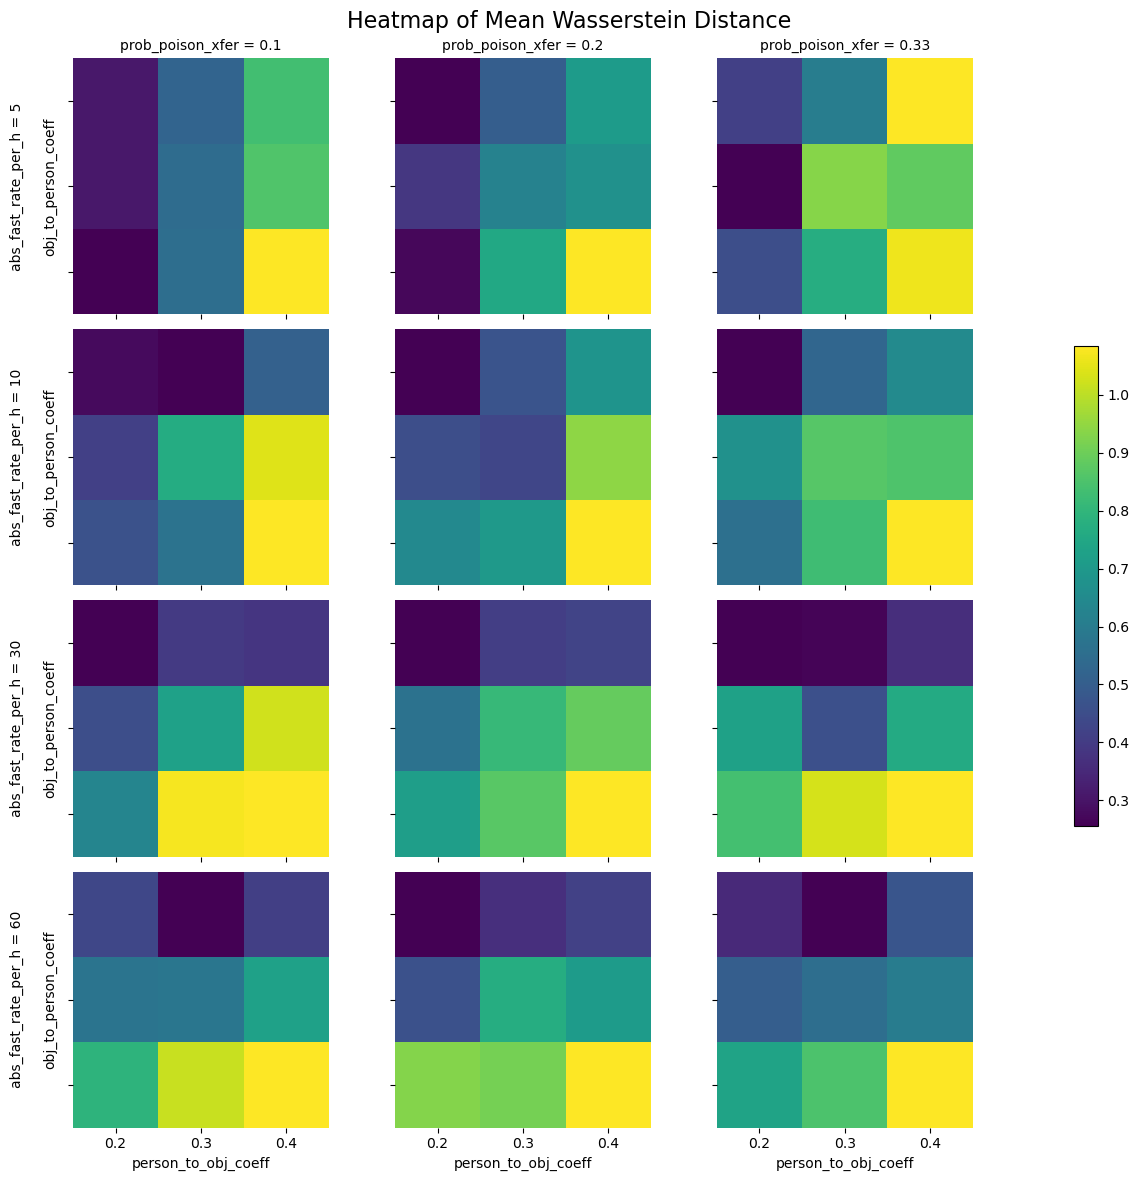

In [19]:
plot_mean_wasserstein_heatmap(
    wasserstein_df,
    outer_x='prob_poison_xfer',
    outer_y='abs_fast_rate_per_h',
    inner_x='person_to_obj_coeff',
    inner_y='obj_to_person_coeff',
    value_col='mean_wasserstein',
    cmap='viridis',
    figsize=(12, 12),
    title_metric='Mean Wasserstein Distance'
)

In [20]:
param_cols = ['prob_poison_xfer', 'person_to_obj_coeff', 'obj_to_person_coeff', 'abs_fast_rate_per_h']

# Convert 'all_distances' into a matrix with a MultiIndex from the parameter columns
distance_matrix_df = pd.DataFrame(
    wasserstein_df['all_distances'].tolist(),
    index=pd.MultiIndex.from_frame(wasserstein_df[param_cols])
)

In [21]:
import skbio.stats as stats
stats.distance.permanova(distance_matrix_df,distance_matrix_df[param_cols])

ModuleNotFoundError: No module named 'skbio'

<Axes: ylabel='Frequency'>

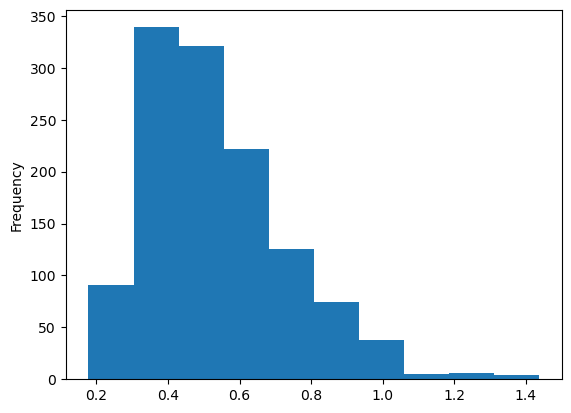

In [22]:
pd.Series(dists).plot(kind='hist', bins=10)

In [23]:
outputs = glob(f"{working_dir}{data_dir}*output*json.gz")
pabsrbs = glob(f"{working_dir}{data_dir}*person_absorption.parquet")
pexchgs = glob(f"{working_dir}{data_dir}*poison_exchange*.parquet")
movewss = glob(f"{working_dir}{data_dir}*walking_start.parquet")
movests = glob(f"{working_dir}{data_dir}*-start.parquet")


init_dfs = ['all_xfer','all_gain','all_loss','all_dist','all_health']

for idf in init_dfs:
    var_exists = idf in locals() or idf in globals()
    if var_exists:
        if len(all_xfer) != len(outputs):
            exec(idf+' = []')
    else:
        exec(idf+' = []')
for i in range(0,len(outputs)):
#for o in outputs:
    o_file = outputs[i].split("/")[-1]
    #o_file = o.split("/")[-1]
    run_id = o_file.split("-")[0]
    run_id = o_file.split("-")[0]
    
    #df = pd.read_json(o,lines=True)
    
    pexchg = pd.read_parquet(pexchgs[i])
    pabsrb = pd.read_parquet(pabsrbs[i])

    pexchg['clock'] = pd.to_datetime(pexchg['time'], unit='s')
    pabsrb['clock'] = pd.to_datetime(pabsrb['time'], unit='s')
    # movews = df.read_parquet(movewss[i])
    # movews.columns = ['aid', 'pid', 'prev_pos_x', 'prev_pos_y', 'prev_time']
    # movest = df.read_parquet(movests[i])
    # movemt = movews.merge(movest,on=['pid','aid'])
    
    ### JSON splitting approach
    #movemt = df[df.aid >0][['aid','event','pid','pos_x','pos_y','time']].copy(deep=True)
    #pexchg = df[df.aid.isnull()][['oid','oid_poison_end', 'oid_poison_start','pid', 'pid_poison_end','pid_poison_start','time']].copy(deep=True)
    
    ### if these dataframes exist don't recalculate them
    if(len(all_xfer) != len(outputs)):
        xfer_stat = poison_exchange_stats(pexchg)
        xfer_stat['run_id'] = run_id
        all_xfer.append(xfer_stat)

    if(len(all_gain) != len(outputs)):
        gain_stat = poison_gain_stats(pexchg)
        gain_stat['run_id'] = run_id
        all_gain.append(gain_stat)

    if(len(all_loss) != len(outputs)):
        loss_stat = poison_loss_stats(pexchg)
        loss_stat['run_id'] = run_id
        all_loss.append(loss_stat)
    
    if(len(all_dist) != len(outputs)):
        dist_stat = distance_poison_traveled(pexchg,objs)
        dist_stat['run_id'] = run_id
        all_dist.append(dist_stat)
    if(len(all_health) != len(outputs)):
        health_stat = health_effects_stats(pabsrb)
        health_stat['run_id'] = run_id
        all_health.append(health_stat)

### if these dataframes exist don't initialize them
# xfer_exists = 'all_xfer' in locals() or 'all_xfer' in globals()
# gain_exists = 'all_gain' in locals() or 'all_gain' in globals()
# loss_exists = 'all_loss' in locals() or 'all_loss' in globals()
# dist_exists = 'all_dist' in locals() or 'all_dist' in globals()
# health_exists = 'all_health' in locals() or 'all_health' in globals()

# if((xfer_exists) | (len(all_xfer) != len(outputs))):
#     all_xfer = []
# if((gain_exists) | (len(all_gain) != len(outputs))):
#     all_gain = []
# if((loss_exists) | (len(all_loss) != len(outputs))):
#     all_loss = []
# if((dist_exists) | (len(all_dist) != len(outputs))):
#     all_dist = []
# if((health_exists) | (len(all_health) != len(outputs))):
#     all_health = []

# init_dfs = ['all_xfer','all_gain','all_loss','all_dist','all_health']

# for idf in init_dfs:
#     var_exists = idf in locals() or idf in globals()
#     if var_exists:
#         if len(all_xfer) != len(outputs):
#             exec(idf+' = []')
#     else:
#         exec(idf+' = []')


all_xfer_df = pd.concat(all_xfer)
all_gain_df = pd.concat(all_gain)
all_loss_df = pd.concat(all_loss)
all_dist_df = pd.concat(all_dist)
all_health_df = pd.concat(all_health)

print(f"Read {len(outputs)} output files in {data_dir}")

/tmp/ipykernel_903622/2175946408.py:61: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  he = health[health.pid == pid].set_index('clock').resample(resampling_time).max()
/tmp/ipykernel_903622/2175946408.py:61: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  he = health[health.pid == pid].set_index('clock').resample(resampling_time).max()
/tmp/ipykernel_903622/2175946408.py:61: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  he = health[health.pid == pid].set_index('clock').resample(resampling_time).max()
/tmp/ipykernel_903622/2175946408.py:61: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  he = health[health.pid == pid].set_index('clock').resample(resampling_time).max()
/tmp/ipykernel_903622/2175946408.py:61: FutureWarning: 'T' is deprecated and will be removed in a future

Read 5400 output files in ../../chem-poison-godot-param-sweep/2025-10-02-1/


In [24]:
health_effects_stats(pabsrb)

/tmp/ipykernel_903622/2175946408.py:61: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  he = health[health.pid == pid].set_index('clock').resample(resampling_time).max()


,num_ill,prop_ill,mean_hours_to_symptom,hours_to_symptom
0,219,0.920168,4.603905,1.925954


In [22]:
pabsrb

,absorbed_poison,pid,poison,time,clock
0,5.000000,380037,195.752193,20447.000000,1970-01-01 05:40:47.000000001
1,5.000000,1689433,139.762894,20447.000000,1970-01-01 05:40:47.000000001
2,10.000000,380037,190.752193,21047.000000,1970-01-01 05:50:47.000000002
3,15.000000,380037,185.752193,21647.000000,1970-01-01 06:00:47.000000003
4,5.000000,4315378,64.254601,21647.000000,1970-01-01 06:00:47.000000003
...,...,...,...,...,...
14731,0.075557,262507,0.006462,75062.777777,1970-01-01 20:51:02.777777186
14732,0.932709,2261851,0.047023,74462.555555,1970-01-01 20:41:02.555554972
14733,0.935060,2261851,0.044672,75062.777777,1970-01-01 20:51:02.777777186
14734,0.009683,2057020,0.019087,74462.555555,1970-01-01 20:41:02.555554972


In [25]:
xfer_plot = all_xfer_df.merge(cfgs[['run_id','prob_poison_xfer','person_to_obj_coeff','obj_to_person_coeff','abs_fast_rate_per_h']])
gain_plot = all_gain_df.merge(cfgs[['run_id','prob_poison_xfer','person_to_obj_coeff','obj_to_person_coeff','abs_fast_rate_per_h']])
loss_plot = all_loss_df.merge(cfgs[['run_id','prob_poison_xfer','person_to_obj_coeff','obj_to_person_coeff','abs_fast_rate_per_h']])
dist_plot = all_dist_df.merge(cfgs[['run_id','prob_poison_xfer','person_to_obj_coeff','obj_to_person_coeff','abs_fast_rate_per_h']])
health_plot = all_health_df.merge(cfgs[['run_id','prob_poison_xfer','person_to_obj_coeff','obj_to_person_coeff','abs_fast_rate_per_h']])

In [26]:
health_plot.sample(3)

,num_ill,prop_ill,mean_hours_to_symptom,hours_to_symptom,run_id,prob_poison_xfer,person_to_obj_coeff,obj_to_person_coeff,abs_fast_rate_per_h
3190,144,0.808989,4.608860,1.913278,2283,0.2,0.2,0.4,10
4722,225,0.941423,4.607712,1.906471,68,0.1,0.2,0.2,10
829,228,0.957983,4.613705,1.924444,2454,0.2,0.3,0.2,10


In [27]:
def mean_wasserstein_across_pairs(runs, column):
    """
    Calculate the mean Wasserstein distance for all unique pairs of dataframes in `dfs`,
    comparing the distributions in the specified `column`.
    """
    from scipy.stats import wasserstein_distance
    import itertools
    distances = []
    # Generate all unique pairs (i < j)
    for run1, run2 in itertools.combinations(runs, 2):
        df1 = pd.read_parquet(f'{data_dir}/{run1}-person_absorption.parquet')
        df2 = pd.read_parquet(f'{data_dir}/{run2}-person_absorption.parquet')

        arr1 = df1[column].dropna().values
        arr2 = df2[column].dropna().values
        dist = wasserstein_distance(arr1, arr2)
        distances.append(dist)
    mean_dist = np.mean(distances) if distances else float('nan')
    return mean_dist, distances

# Example usage:
# dfs = [df1, df2, df3]
# mean_dist, all_dists = mean_wasserstein_across_pairs(dfs, 'pid_poison_end')
# print(f'Mean Wasserstein distance: {mean_dist}')
# print(f'All pairwise distances: {all_dists}')

In [39]:
cfgs[(cfgs.prob_poison_xfer == 0.10) &
     (cfgs.person_to_obj_coeff == 0.2) &
     (cfgs.obj_to_person_coeff == 0.2) &
     (cfgs.abs_fast_rate_per_h == 10)].sample(5)
     

,person_file,schedule_file,output_file,sim_speed_scale,save_every_s,prob_poison_xfer,person_to_obj_coeff,obj_to_person_coeff,max_person_gain,initial_poison,abs_tick_duration_m,abs_fast_poison_threshold,abs_fast_rate_per_h,abs_slow_frac_rate_per_h,abs_obj_absorption_frac,run_id,cell,replicate,output,schedule
1972,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/scratch/pb5gj/chem-poison-godot-param-sweep/7...,1.0,5,0.1,0.2,0.2,250.0,5000.0,10.0,25,10,0.3,0.3,77,1,27,77-output.json,schedule_limitedCR_v4.json
2790,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/scratch/pb5gj/chem-poison-godot-param-sweep/7...,1.0,5,0.1,0.2,0.2,250.0,5000.0,10.0,25,10,0.3,0.3,73,1,23,73-output.json,schedule_limitedCR_v4.json
2473,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/scratch/pb5gj/chem-poison-godot-param-sweep/5...,1.0,5,0.1,0.2,0.2,250.0,5000.0,10.0,25,10,0.3,0.3,57,1,7,57-output.json,schedule_limitedCR_v4.json
1207,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/scratch/pb5gj/chem-poison-godot-param-sweep/7...,1.0,5,0.1,0.2,0.2,250.0,5000.0,10.0,25,10,0.3,0.3,71,1,21,71-output.json,schedule_limitedCR_v4.json
268,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/project/bii_nssac/biocomplexity/dtra/Toxin_Bu...,/scratch/pb5gj/chem-poison-godot-param-sweep/6...,1.0,5,0.1,0.2,0.2,250.0,5000.0,10.0,25,10,0.3,0.3,60,1,10,60-output.json,schedule_limitedCR_v4.json


In [29]:
cfgs.groupby(['prob_poison_xfer','person_to_obj_coeff','obj_to_person_coeff','abs_fast_rate_per_h']).run_id.count()

prob_poison_xfer  person_to_obj_coeff  obj_to_person_coeff  abs_fast_rate_per_h
0.10              0.2                  0.2                  5                      50
                                                            10                     50
                                                            30                     50
                                                            60                     50
                                       0.3                  5                      50
                                                                                   ..
0.33              0.4                  0.3                  60                     50
                                       0.4                  5                      50
                                                            10                     50
                                                            30                     50
                                                            

In [41]:
###  Make heatmaps based on "plot" dataframes

def plot_grid_of_heatmaps(
    df, 
    outer_x, outer_y, 
    inner_x, inner_y, 
    value_col, 
    aggfunc='mean', 
    cmap='viridis',
    figsize=(12, 12),
    title_metric = '',
    out_dir = 'plots/param-sweep_2025-10-02/'
):
    outer_x_vals = sorted(df[outer_x].unique())
    outer_y_vals = sorted(df[outer_y].unique())
    
    ncols = len(outer_x_vals)
    nrows = len(outer_y_vals)

    fig, axes = plt.subplots(len(outer_y_vals), len(outer_x_vals), figsize=figsize, sharex=True, sharey=True)

    if len(outer_y_vals) == 1 and len(outer_x_vals) == 1:
        axes = np.array([[axes]])
    elif len(outer_y_vals) == 1:
        axes = np.array([axes])
    elif len(outer_x_vals) == 1:
        axes = np.array([[ax] for ax in axes])

    for i, oy in enumerate(outer_y_vals):
        for j, ox in enumerate(outer_x_vals):
            ax = axes[i, j]
            subset = df[(df[outer_x] == ox) & (df[outer_y] == oy)]

            if subset.empty:
                ax.axis('off')
                continue

            pivot = subset.pivot_table(
                index=inner_y,
                columns=inner_x,
                values=value_col,
                aggfunc=aggfunc
            )

            sns.heatmap(
                pivot, ax=ax, cmap=cmap, cbar=False,
                square=True, xticklabels=True, yticklabels=True
            )

            # Label inner x and y only on outer edge
            if i < nrows - 1:
                ax.set_xticklabels([])
                ax.set_xlabel("")
            else:
                ax.set_xlabel(inner_x)

            if j > 0:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            else:
                ax.set_ylabel(inner_y)

            # Label outer variables
            if i == 0:
                ax.set_title(f"{outer_x} = {ox}", fontsize=10)
            if j == 0:
                ax.annotate(
                    f"{outer_y} = {oy}", 
                    xy=(0, 0.5), 
                    xytext=(-ax.yaxis.labelpad - 10, 0),
                    xycoords=ax.yaxis.label,
                    textcoords='offset points',
                    size='medium',
                    ha='right', va='center', rotation=90
                )
    # Common colorbar
    cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
    norm = plt.Normalize(df[value_col].min(), df[value_col].max())
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    title_string = f"Heatmap of the {value_col} for {title_metric}summarized by {value_col}"
    print(title_string)
    fig.suptitle(title_string, fontsize=16)
    fig.colorbar(sm, cax=cbar_ax)
    # plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.tight_layout()
    file_name = title_string.replace(" ","_").replace("\n","_").lower()
    plt.savefig(f'{out_dir}{file_name}.png',dpi=150)
    #plt.show()
    plt.close(fig)

In [42]:
def plot_grid_of_lineplots(
    df,
    outer_x, outer_y,
    x_axis,
    lines,
    value_col,
    aggfunc='mean',
    figsize=(12, 12),
    title_metric = '', 
    out_dir = '',
    show=False):
    """
    Create a grid of line plots, where each subplot corresponds to a combination
    of outer_x and outer_y, and within each subplot, lines are grouped by `lines`.
    """

    outer_x_vals = sorted(df[outer_x].unique())
    outer_y_vals = sorted(df[outer_y].unique())

    ncols = len(outer_x_vals)
    nrows = len(outer_y_vals)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    for i, oy in enumerate(outer_y_vals):
        for j, ox in enumerate(outer_x_vals):
            ax = axes[i, j]
            subset = df[(df[outer_x] == ox) & (df[outer_y] == oy)]

            if subset.empty:
                ax.axis('off')
                continue

            # Aggregate values for clean plotting
            grouped = (
                subset
                .groupby([x_axis, lines])[value_col]
                .agg(aggfunc)
                .reset_index()
            )

            for line_id, group in grouped.groupby(lines):
                ax.plot(group[x_axis], group[value_col], label=str(line_id))

            # Inner axis labels
            if i < nrows - 1:
                ax.set_xlabel("")
            else:
                ax.set_xlabel(x_axis)

            if j > 0:
                ax.set_ylabel("")
            else:
                ax.set_ylabel(value_col)

            # Outer labels
            if i == 0:
                ax.set_title(f"{outer_x}={ox}", fontsize=10)
            if j == 0:
                ax.annotate(
                    f"{outer_y}={oy}",
                    xy=(0, 0.5),
                    xytext=(-ax.yaxis.labelpad - 10, 0),
                    xycoords=ax.yaxis.label,
                    textcoords='offset points',
                    size='medium',
                    ha='right', va='center', rotation=90
                )

    title_string = f"Sensitivity of the {value_col} for {title_metric}summarized by {value_col}"
    fig.suptitle(title_string, fontsize=16, y=1.02)

    # Put legend outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
    handles, labels,
    title=lines,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0)
    # handles, labels = ax.get_legend_handles_labels()
    # fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.12, 1.0))

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    file_name = title_string.replace(" ","_").replace("\n","_").lower()
    plt.savefig(f'{out_dir}{file_name}.png',dpi=150)
    if show:
        plt.show()
    else:
        plt.close(fig)

In [46]:
plot_grid_of_heatmaps(
    health_plot,
    'prob_poison_xfer', 'abs_fast_rate_per_h',
    'person_to_obj_coeff', 'obj_to_person_coeff',
    'num_ill',
    aggfunc='mean',
    figsize=(12, 12),
    title_metric='health outcomes',
    out_dir = out_dir
    )

Heatmap of the num_ill for health outcomessummarized by num_ill


/tmp/ipykernel_903622/2119634295.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [56]:
# Define a dictionary to customize the summarizer for each dataframe
summarizer_dict = {
    'gain_plot': ['mean', 'std', 'max'],
    'dist_plot': ['mean', 'count'],
    'health_plot': ['num_ill']
}

# Define the dataframes and their descriptions
dfs_to_plot = {
    'gain_plot': gain_plot,
    'dist_plot': dist_plot,
    'health_plot': health_plot
}

dfs_descrip = {
    'gain_plot': 'gains of poison by people',
    'dist_plot': 'distance traveled by poison',
    'health_plot': 'health outcomes'
}

# Output directory for the plots
out_dir = f'{working_dir}plots/param-sweep_2025-09-11/'

# Iterate over the dataframes and their corresponding summarizers
for key, df in dfs_to_plot.items():
    description = dfs_descrip[key]
    summarizers = summarizer_dict[key]
    
    for summarizer in summarizers:
        plot_grid_of_lineplots(
            df,
            outer_x='person_to_obj_coeff',
            outer_y='obj_to_person_coeff',
            x_axis='abs_fast_rate_per_h',
            lines='prob_poison_xfer',
            value_col=summarizer,
            aggfunc='mean',
            figsize=(12, 12),
            out_dir=out_dir,
            title_metric=description
        )
        plot_grid_of_heatmaps(
            df,
            'prob_poison_xfer', 'abs_fast_rate_per_h',
            'person_to_obj_coeff', 'obj_to_person_coeff',
            value_col  = summarizer,
            aggfunc='mean',
            figsize=(12, 12),
            title_metric=description,
            out_dir = out_dir
            )

Heatmap of the mean for gains of poison by peoplesummarized by mean


/tmp/ipykernel_903622/2119634295.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Heatmap of the std for gains of poison by peoplesummarized by std


/tmp/ipykernel_903622/2119634295.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Heatmap of the max for gains of poison by peoplesummarized by max


...

/tmp/ipykernel_903622/2119634295.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Heatmap of the count for distance traveled by poisonsummarized by count


/tmp/ipykernel_903622/2119634295.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Heatmap of the num_ill for health outcomessummarized by num_ill


/tmp/ipykernel_903622/2119634295.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Heatmap of the mean for gains of poison by peoplesummarized by mean


/tmp/ipykernel_903622/2119634295.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Heatmap of the std for gains of poison by peoplesummarized by std


/tmp/ipykernel_903622/2119634295.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Heatmap of the count for gains of poison by peoplesummarized by count


...

Heatmap of the count for distance traveled by poisonsummarized by count


/tmp/ipykernel_903622/2119634295.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Heatmap of the max for distance traveled by poisonsummarized by max


/tmp/ipykernel_903622/2119634295.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


KeyError: 'mean'

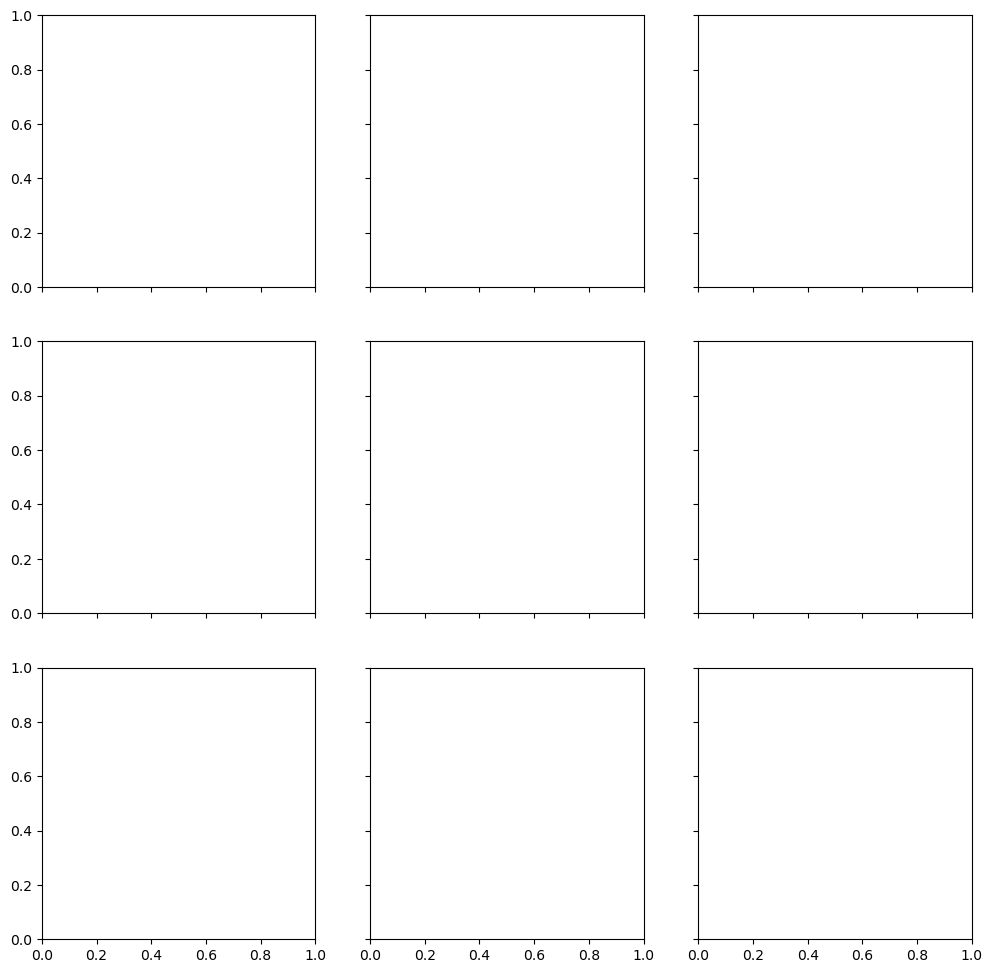

In [50]:
##  Plot lots of sensitivities with line plots
out_dir = f'{working_dir}plots/param-sweep_2025-10-02/'
dfs_to_plot = [gain_plot,dist_plot,health_plot]
dfs_descrip = ['gains of poison by people','distance traveled by poison','health outcomes']
summarizers = ['mean','std','count','max']

for i in range(0,len(dfs_to_plot)):
    df = dfs_to_plot[i]
    description = dfs_descrip[i]
    for s in summarizers:
        plot_grid_of_heatmaps(
            df,
            'person_to_obj_coeff', 'obj_to_person_coeff',
            'abs_fast_rate_per_h',
            'prob_poison_xfer', 
            s,
            aggfunc='mean',
            figsize=(12, 12),
            out_dir = out_dir,
            title_metric=description)

Heatmap of the mean for total poison transfers
summarized by mean


/tmp/ipykernel_903622/1381939415.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: 'plots/param-sweep_2025-10-02/heatmap_of_the_mean_for_total_poison_transfers_summarized_by_mean.png'

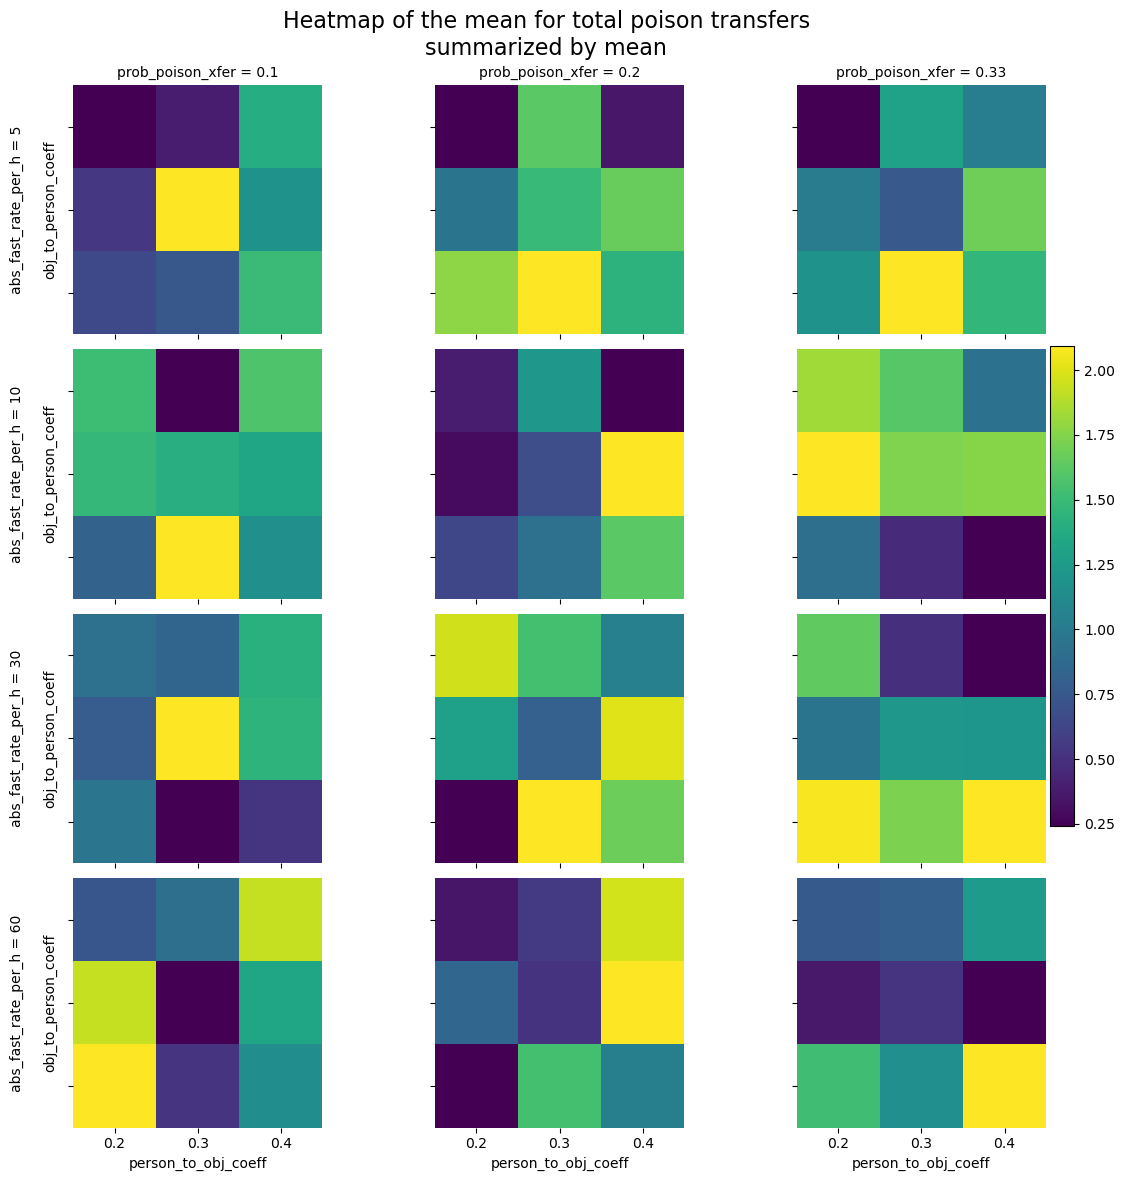

In [38]:
### Plot lots of heatmaps

dfs_to_plot = [xfer_plot,gain_plot,loss_plot,dist_plot]
dfs_descrip = ['total poison transfers','gains of poison by people','shedding poison by people','distance traveled by poison']
summarizers = ['mean','std','count','max']

for i in range(0,len(dfs_to_plot)):
    df = dfs_to_plot[i]
    description = dfs_descrip[i]
    for s in summarizers:
        plot_grid_of_heatmaps(
        df,
        'prob_poison_xfer', 'abs_fast_rate_per_h',
        'person_to_obj_coeff', 'obj_to_person_coeff',
        s, 
        aggfunc='mean', 
        cmap='viridis',
        figsize=(12, 12),
        title_metric = description)

Sensitivity of the mean for gains in poison
summarized by mean


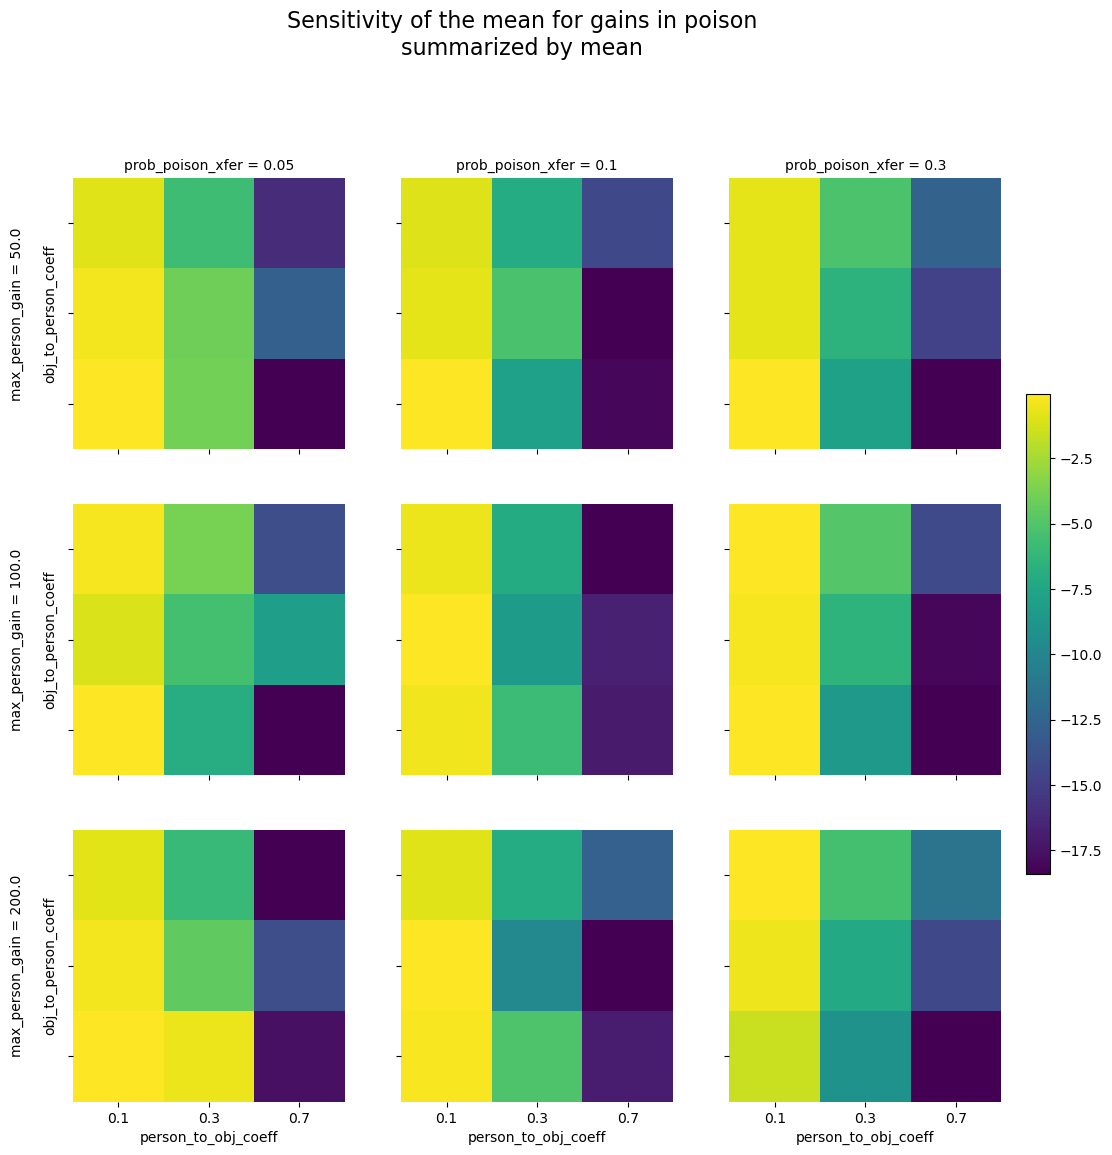

In [ ]:
plot_grid_of_heatmaps(
    loss_plot,
    'prob_poison_xfer', 'max_person_gain',
    'person_to_obj_coeff', 'obj_to_person_coeff',
    'mean', 
    aggfunc='mean', 
    cmap='viridis',
    figsize=(12, 12),
    title_metric = "gains in poison"
)

Sensitivity of the count for gains in poison
summarized by mean


/tmp/ipykernel_107302/2756743894.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


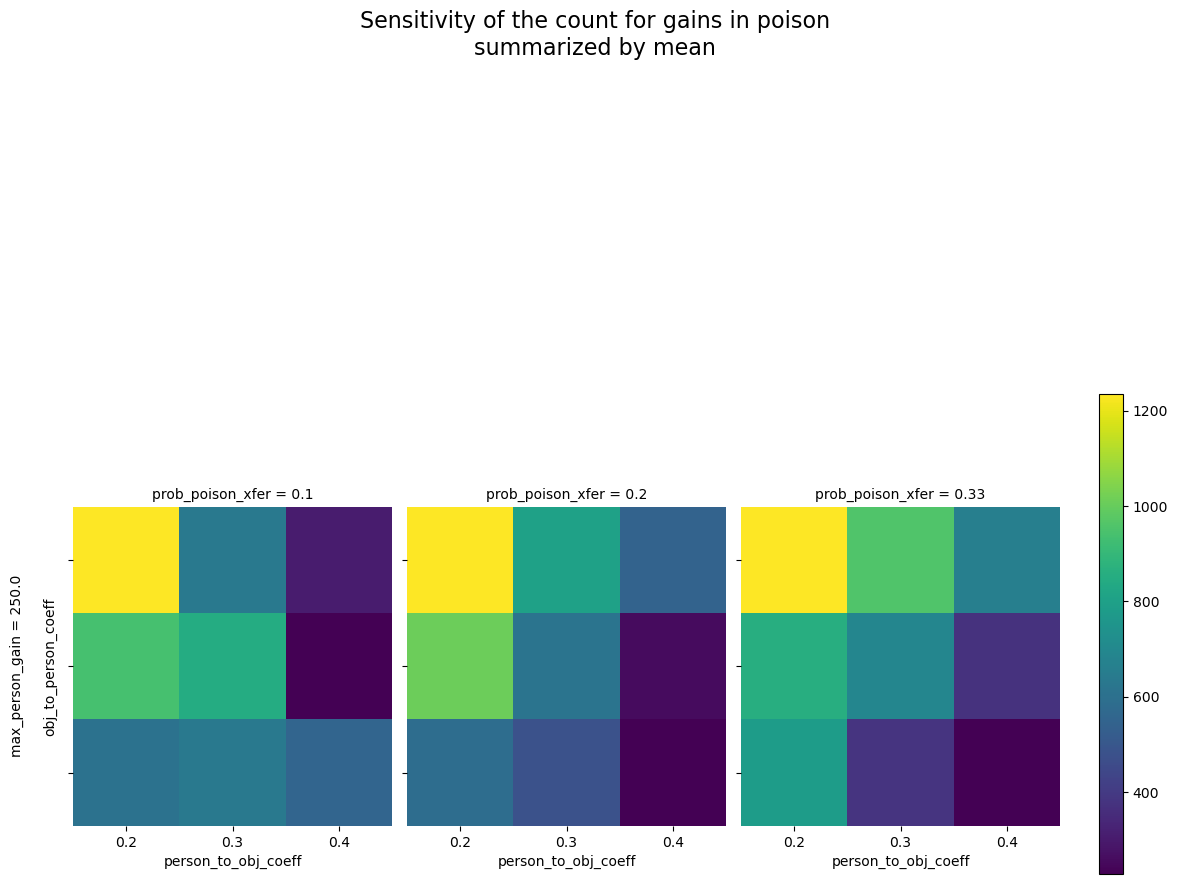

In [ ]:
plot_grid_of_heatmaps(
    gain_plot,
    'prob_poison_xfer', 'max_person_gain',
    'person_to_obj_coeff', 'obj_to_person_coeff',
    'count', 
    aggfunc='mean', 
    cmap='viridis',
    figsize=(12, 12),
    title_metric = "gains in poison"
)

In [ ]:
pe = pexchg[pexchg['poison_xfer'] != 0.00]
one = pd.DataFrame(pe['poison_xfer'].describe()).T
one['id'] = 1
two = pd.DataFrame(pe['poison_xfer'].describe()).T
two['id']=2
pd.concat([one,two])


NameError: name 'pexchg' is not defined

In [ ]:
# min_ts = pd.pivot_table(pexchg,values='pid_poison_end',index='clock',columns='pid').ffill()

# gains = min_ts.fillna(0.0).diff().clip(lower=0).resample(resampling_time).sum()
# losses = min_ts.fillna(0.0).diff().clip(upper=0).resample(resampling_time).sum()